## Imports

In [1]:
from RegionMap import RegionMap
from Fleet import Monitoring_Fleet

import matplotlib.pyplot as plt
import numpy as np
import os 
from datetime import datetime
import pandas as pd

In [2]:
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

## Set up

In [4]:
# Path to load the data

# Amélie
# link = r"D:\EPFL\MA2\Projet\Code\Data\datasets\simbarca\all_agg"
# df_link = pd.read_csv(r"D:\EPFL\MA2\Projet\Code\Data\datasets\simbarca\all_agg\metadata\link_bboxes_clustered.csv")

# Amélie PC
link = r"E:\datasets\simbarca\all_agg"
df_link = pd.read_csv(r"E:\datasets\simbarca\all_agg\metadata\link_bboxes_clustered.csv")

# # Orane
# link = r"C:\Users\orane\Documents\EPFL\GC\Master\MA2\Projet LUTS\all_agg\datasets\simbarca\all_agg"
# df_link = pd.read_csv(r"C:\Users\orane\Documents\EPFL\GC\Master\MA2\Projet LUTS\all_agg\datasets\simbarca\all_agg\metadata\link_bboxes_clustered.csv")

In [5]:
def run(link, df_link, File, id = 'pred_vdist', mode = 'random', load = True, pretrained_folder = None):

    
    # Set the parameters
    N_episodes = 26 # 26 
    ep_len     = 5

    buffer_size = 6000
    batch_size = 32

    # --- Create maps --- 

    # Map parameters
    x_size = 20
    y_size = 30


    Map = RegionMap(y_size, x_size, [], [], 1, df_link = df_link, link = link, listFileNumbers=File, load = load)
    Map.initialize_better_importance_map(id)

    # ----- Create a fleet -----
    
    drone_init_pos = [[5,7], [3,26], [10, 3], [10,26]]

    state_shape    = [ep_len, 13]    
    num_stacked = 2    
    alpha = 1e-3

    F = Monitoring_Fleet(Map, buffer_size, state_shape, pretrained_folder, lstm = False, gru = True, num_stacked = num_stacked, alpha = alpha)
    F.add_drones(drone_init_pos) 


    #----- Create save folder paths -----
    
    np.set_printoptions(threshold=np.inf)
    
    current_folder = os.getcwd()
    save_folder = current_folder + "/Results"
    if not os.path.exists(save_folder):
        os.makedirs(save_folder)    
        
    now = datetime.now()
    date_time = now.strftime("%m_%d_%Y_%H_%M_%S")    
    
    current_results = save_folder + "/" + date_time
    if not os.path.exists(current_results):
        os.makedirs(current_results)

   #----- Simultaion -----
    
    t_curr = 0
    
    ep_curr = 0 
    
    T = Map.importance_map.shape[0]-1

    list_of_importance_metric = []
    list_of_patrol_metric     = []
    list_of_reward_metric     = []
    
    while ep_curr < N_episodes:

        print('Episode: ',ep_curr)
        
        ep_step = 0
        
        while ep_step < ep_len:  

            # ------------------------------------------------------------------------------------------
            print('Time | ep_step: ', t_curr, ep_step)

            if t_curr % 10 == 0:
                F.plot_fleets_trajectories(t_curr, T, masked=True)
            
            if t_curr == 0:
            
                list_of_observations, list_of_drone_positions = F.get_fleet_info(t_curr, T)
                list_of_drone_states = F.get_drone_states(list_of_observations, list_of_drone_positions)
                visit_matrix = F.visit_matrix
                
                F.update_drone_state_history(list_of_drone_states)                   
            
        #------------- MOVE -------------------------------------------------------------------------------------
            if mode == 'random':
                list_of_actions = F.move_drones_random(list_of_drone_states, list_of_observations, discount_param=0.1, recover_param=0.025)
            elif mode == 'greedy':
                list_of_actions = F.move_drones_greedy(list_of_drone_states, list_of_observations, discount_param=0.1, recover_param=0.025)
            elif mode == 'zigzag':
                list_of_actions = F.move
            else:
                if t_curr > ep_len:
                    # function works the same for GRU or LSTM, it is just not the same policy network used
                    list_of_actions = F.move_drones_LSTM(list_of_drone_states, list_of_observations, discount_param=0.1, recover_param=0.025)
                
                else:
                    list_of_actions = F.move_drones_random(list_of_drone_states, list_of_observations, discount_param=0.1, recover_param=0.025)

            #--------------------------------------------------------------------------------------------------------------------
            
            F.update_drone_action_history(list_of_actions)
            
            list_of_observations_, list_of_drone_positions_ = F.get_fleet_info(t_curr+1, T)
            list_of_drone_states_ = F.get_drone_states(list_of_observations_, list_of_drone_positions_)
            visit_matrix_ = F.visit_matrix
            
            F.update_drone_state_history(list_of_drone_states_)
        
            #----- Reward calculation -----
        
            list_of_rewards = F.get_reward(list_of_observations, list_of_observations_, visit_matrix, visit_matrix_, alpha1=1.0, alpha2=0.5)
            
            print(list_of_rewards)
            
            F.update_drone_reward_history(list_of_rewards)
        
            #----- Collect metrics -----
        
            importance_metric, patrol_metric, reward_metric = F.get_metrics(list_of_rewards)
        
            list_of_importance_metric.append(importance_metric)
            list_of_patrol_metric.append(patrol_metric)
            list_of_reward_metric.append(reward_metric)  
            
            #----- Re-assign states for next iteration -----
        
            list_of_observations    = list_of_observations_
            list_of_drone_positions = list_of_drone_positions_
            list_of_drone_states    = list_of_drone_states_
        
            t_curr  += 1 
            ep_step +=1

        #----- Store transitions in the buffer -----
            
        ep_curr += 1
        
        print("-----------")
    
    F.create_data_set()
    
    F.buffer.save(current_results)

    #----- Save metrics -----
    
    np.save(current_results + "/list_of_importance_metric.npy", np.array(list_of_importance_metric))
    np.save(current_results + "/list_of_patrol_metric.npy"    , np.array(list_of_patrol_metric))
    np.save(current_results + "/list_of_reward_metric.npy"    , np.array(list_of_reward_metric))
    np.save(current_results + "/list_of_perc_visited.npy"     , np.array(F.procentage_visited))

## Run

Episode:  0
Time | ep_step:  0 0


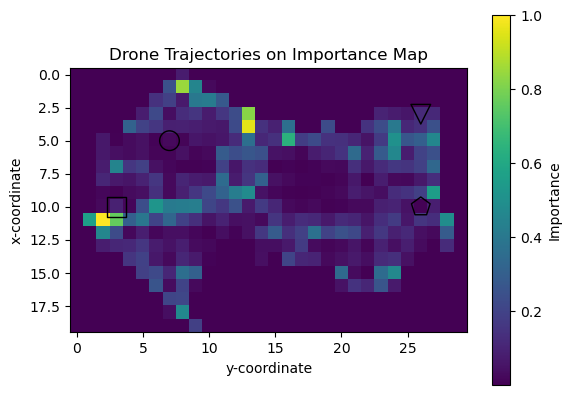

[2.277122551575303, 4.0475537391209855, -0.7929345685988665, 0.9866307484155645]
Time | ep_step:  1 1
[2.1565236952155824, -6.987507541274454, -1.768839091993868, 1.3627938279712448]
Time | ep_step:  2 2
[-3.8506163582205764, -0.04287323206663113, 0.5800131736323239, -3.246864867938484]
Time | ep_step:  3 3
[5.403369664214552, 4.514901456236838, 5.247663681395352, 2.8442330304533248]
Time | ep_step:  4 4
[8.043920408003032, -4.67969579514116, 0.7752220848575236, 5.844958641566336]
-----------
Episode:  1
Time | ep_step:  5 0
[-8.746177008375525, 9.733675273860072, 2.3516340440308783, 0.6618364905735918]
Time | ep_step:  6 1
[10.197787974029781, 2.1484080332517936, 6.97952176630497, 5.99632249843242]
Time | ep_step:  7 2
[4.51580318249762, 4.168076165185568, -8.236388247832656, 3.977939814329148]
Time | ep_step:  8 3
[6.180324532091618, -0.7500099999999743, 7.668024944514037, 5.032206952571869]
Time | ep_step:  9 4
[2.6962603852152833, 0.8750008749999969, -0.105674929358065, 4.211542189

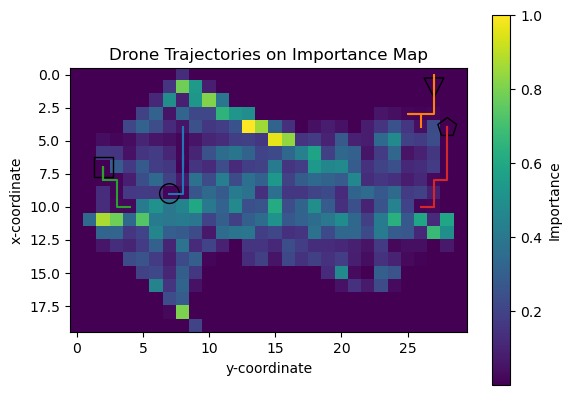

[10.877172192558646, 0.5151755354505136, -7.010157858021557, -1.8279388882219783]
Time | ep_step:  11 1
[2.7470348794013266, 3.158977166454422, 7.0790138030052185, 4.209822314549493]
Time | ep_step:  12 2
[-6.490027368068696, -3.2699018805237157, 0.025179813502587134, -5.045748728618782]
Time | ep_step:  13 3
[-5.78644801340997, 3.2775075305868495, 0.1806362280240871, 3.2775075305868495]
Time | ep_step:  14 4
[5.703476717695592, 6.34975117708375, 3.624683299567551, 6.34975117708375]
-----------
Episode:  3
Time | ep_step:  15 0
[5.415454716235397, 7.859657794521107, 4.25, 7.859657794521107]
Time | ep_step:  16 1
[10.07180256471038, 5.9458120182817, 4.25, -1.1748977452906462]
Time | ep_step:  17 2
[2.8442356437444682, 2.7666232579116814, 7.698984755744959, 0.8626449427403965]
Time | ep_step:  18 3
[-0.7459400966763485, 4.661416398799897, 0.8010152442550411, 1.6136761153536783]
Time | ep_step:  19 4
[8.862330425530672, 5.435953849941, 4.25, 4.011464293663999]
-----------
Episode:  4
Time

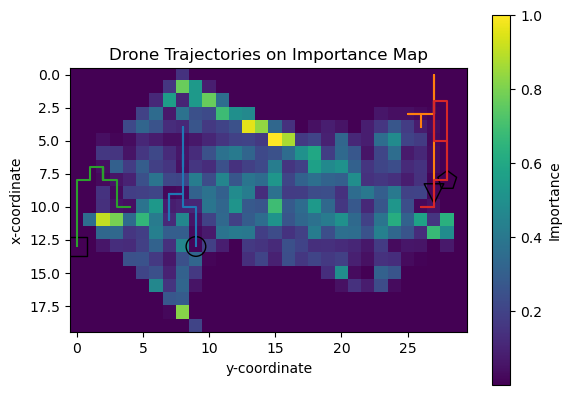

[-9.602113058790565, 6.233091546874494, 4.25, 4.63263082661539]
Time | ep_step:  21 1
[4.016029362007977, 27.323489897774333, 4.25, 10.372739110312736]
Time | ep_step:  22 2
[1.089313080161809, -2.2451362757274196, 4.25, 3.9535214614664937]
Time | ep_step:  23 3
[4.858389410376548, 3.7284916813480318, 4.25, 1.0990234630394025]
Time | ep_step:  24 4
[4.713953964412216, 2.2678676389022034, 4.25, -5.784856797151091]
-----------
Episode:  5
Time | ep_step:  25 0
[0.221837010234594, -0.014734386053953594, -4.125009124999978, 0.05156761224889686]
Time | ep_step:  26 1
[5.044876405969263, 4.03271527337509, 4.000007374999982, 4.89702553126622]
Time | ep_step:  27 2
[4.6412083096802235, 4.700000899999997, -0.31250912499997696, 2.706976112827626]
Time | ep_step:  28 3
[6.140504198148847, 4.25, 9.687510874999973, 3.8016991594141523]
Time | ep_step:  29 4
[11.644524354487656, 4.25, 4.25, 4.4923694649198245]
-----------
Episode:  6
Time | ep_step:  30 0


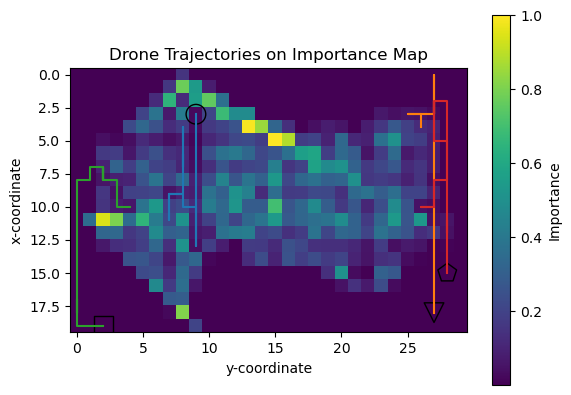

[7.0520877204835415, -0.7500099999999743, 4.25, 4.125]
Time | ep_step:  31 1
[-1.0664907866919282, 0.8750008749999969, 4.25, 4.125]
Time | ep_step:  32 2
[-8.438698871301654, 0.49999092500002223, 4.25, 4.349998625000004]
Time | ep_step:  33 3
[9.75766783620739, 1.1875010999999973, 4.25, -0.18750862499997756]
Time | ep_step:  34 4
[2.339896913994579, 0.9625001999999989, 4.460599380155827, 0.3125]
-----------
Episode:  7
Time | ep_step:  35 0
[11.696221996098757, 1.8416531446724185, 14.573510358651902, 0.27499972500000036]
Time | ep_step:  36 1
[-3.840986538678405, 5.2023179143213705, 2.649088484941217, 0.962500649999999]
Time | ep_step:  37 2
[0.8114729970693579, 2.3348771189604864, -9.96366234162018, 1.1875006499999987]
Time | ep_step:  38 3
[-1.144996687769888, 5.539133112623677, 9.280106565344399, 1.6505270815301598]
Time | ep_step:  39 4
[3.7906386638060234, -2.7768225391581502, 5.850129445795929, 2.361244296647303]
-----------
Episode:  8
Time | ep_step:  40 0


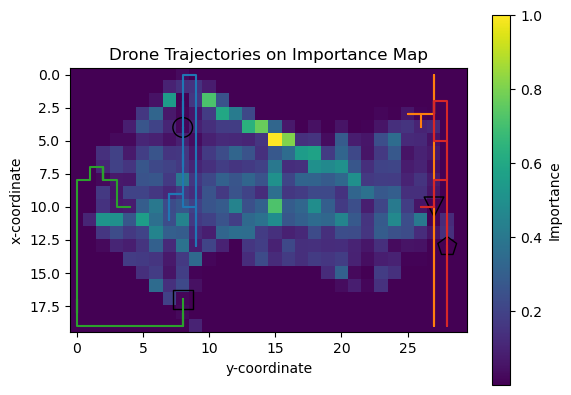

[3.3911158973351165, 3.2670042146098908, 3.1400683807039513, 2.1055572421775075]
Time | ep_step:  41 1
[-5.139584346208723, 3.1817415288736726, 2.6493341778405015, 0.8648810755004449]
Time | ep_step:  42 2
[4.408520114351997, 2.9152922816051374, 7.0496424925513566, 2.474741974022244]
Time | ep_step:  43 3
[-3.8279741848120508, 3.358491010278298, 1.744764576666059, 2.6418105863006818]
Time | ep_step:  44 4
[1.4443848730996247, 3.657148338690235, 5.635931123048065, 2.8280197874250335]
-----------
Episode:  9
Time | ep_step:  45 0
[10.48700979184359, 3.0862658892017447, 5.752163938060411, 2.898001699754167]
Time | ep_step:  46 1
[-4.336589539051055, 2.923583226525351, 4.819539633020762, 3.2905862238822357]
Time | ep_step:  47 2
[-5.878253031436481, 4.03498439913057, -1.2018045256286902, 4.227673915282186]
Time | ep_step:  48 3
[6.044439468447247, 4.300484572590272, 5.196235077977176, 4.201290978664474]
Time | ep_step:  49 4
[-6.502826757186302, -0.6752223504249749, 2.2400392410904173, 4.1

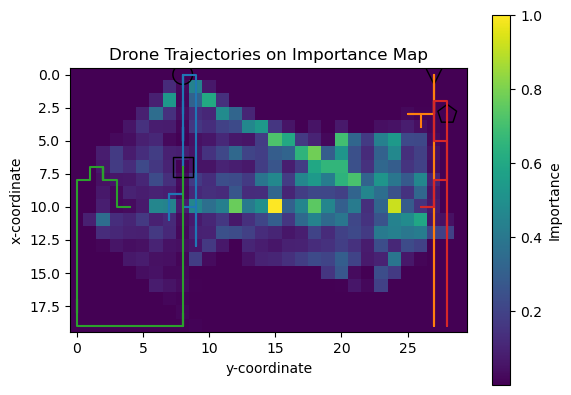

[7.484300177162419, 4.2687500375, 7.104880635626611, -4.058142451496025]
Time | ep_step:  51 1
[4.172307500072982, 5.106251712499996, 2.6223108796402816, 3.9376895014203046]
Time | ep_step:  52 2
[6.265570008428851, -5.106260837499974, -0.5736025855760096, 4.538181717627364]
Time | ep_step:  53 3
[-1.7534055825322858, 8.250008249999981, 5.538617021299435, 4.618538487074996]
Time | ep_step:  54 4
[1.4534746389836086, 4.687500874999998, 11.560039583593607, -0.8562599624999744]
-----------
Episode:  11
Time | ep_step:  55 0
[2.8482054141117286, 4.25, -2.717817392572762, -3.9562594374999756]
Time | ep_step:  56 1
[-2.4376691127754757, 4.25, 2.5557431456040822, 3.831257287499981]
Time | ep_step:  57 2
[-3.1151512964535493, 9.250009999999975, -2.8128738577816548, -3.7062573399999814]
Time | ep_step:  58 3
[1.270157755534165, 4.25, 3.3108393675605345, 3.1752167091749897]
Time | ep_step:  59 4
[2.022839269787074, 4.367487006431247, -2.067583723548324, 5.451729375369449]
-----------
Episode:  1

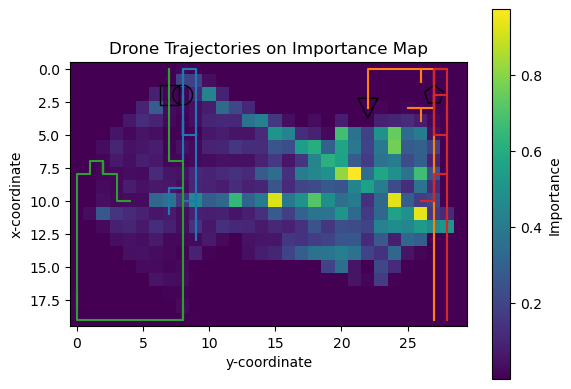

[0.37567340368405006, 6.558776204084779, 4.620457403324544, 1.720180138950437]
Time | ep_step:  61 1
[-1.8663852939474335, 12.202184391058953, -4.628135914299636, 3.2419694702444115]
Time | ep_step:  62 2
[3.202981569991884, 2.5336568596053155, 2.6282809387706214, 5.417721653889989]
Time | ep_step:  63 3
[8.808815501457536, 3.7653778307139874, -0.2051517783710735, 2.9167478399281666]
Time | ep_step:  64 4
[4.650000799999997, -2.814483113586903, 1.3399514154130576, 4.869394303456441]
-----------
Episode:  13
Time | ep_step:  65 0
[9.250009999999975, 2.456116547808053, -2.8155327146695925, 4.814414188661175]
Time | ep_step:  66 1
[5.165835467319539, -4.7374130297452215, 2.0820860486587516, 0.7352059025764246]
Time | ep_step:  67 2
[5.474061733352187, 3.995191182186834, -2.2943458441775286, 1.9297861244006302]
Time | ep_step:  68 3
[3.2891796188471014, -7.726856081962468, 1.7139816599619855, 17.52321287008424]
Time | ep_step:  69 4
[4.605596001259983, 8.021829727772921, 0.8068919038743791

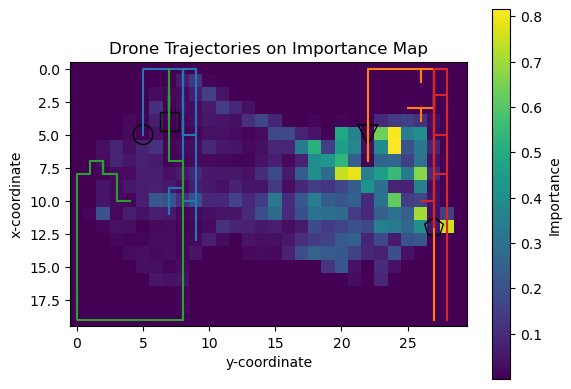

[5.131737362593412, 0.19560983643452268, 2.442558503769913, -6.061276341198251]
Time | ep_step:  71 1
[3.4447711193934087, -0.9455330512175664, 6.0016423127061, -7.677376786363032]
Time | ep_step:  72 2
[4.284938829950988, -7.4394374437461375, 2.711428097425961, 5.365943487183649]
Time | ep_step:  73 3
[4.362163592129946, 6.525923693911454, 5.708456361619756, 2.079410987838113]
Time | ep_step:  74 4
[-0.41191999092698106, 12.427139880157267, 1.4736254274053537, -2.960398476677338]
-----------
Episode:  15
Time | ep_step:  75 0
[5.832216674229132, -10.479837953019963, 4.917641545337628, -3.0081344904748164]
Time | ep_step:  76 1
[3.103538600215688, 8.289304547722345, 7.572713804377243, 11.446703516717296]
Time | ep_step:  77 2
[3.5911754481494427, 6.316982581758872, -0.09210667757130808, 0.3090707235535628]
Time | ep_step:  78 3
[4.1621909057721505, 3.8514488269202385, 3.0489326480450125, -4.999178334779764]
Time | ep_step:  79 4
[3.5937108108012126, -2.2403031071647996, 4.1901541048893

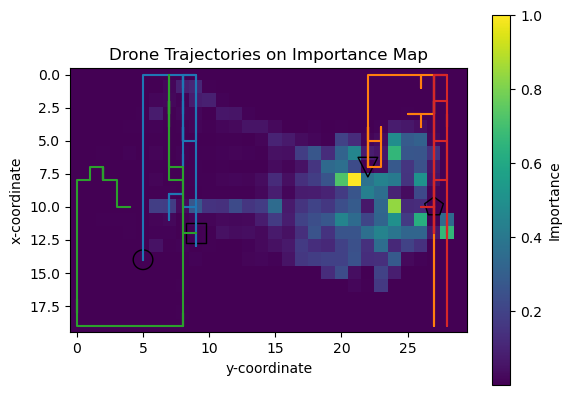

[4.201598522897144, 22.34786601234228, 4.25630711838603, 3.532676733073508]
Time | ep_step:  81 1
[4.254426712257555, -9.067248155176642, 4.051890345836455, 6.294952543420671]
Time | ep_step:  82 2
[4.239778591758096, 4.296814505010844, 4.267440550254492, -0.6153435085413206]
Time | ep_step:  83 3
[4.25, -4.098542405292393, 4.212304269638054, -0.5513349953147062]
Time | ep_step:  84 4
[-0.7500099999999743, 12.836791696026921, -4.0963057420348585, -1.5833841832527202]
-----------
Episode:  17
Time | ep_step:  85 0
[0.8750008749999969, -7.253082316368818, 0.4113162485842404, 1.640076094134094]
Time | ep_step:  86 1
[0.3749996750000017, 0.2680338099598889, 1.1333640929228659, 3.3355331706296676]
Time | ep_step:  87 2
[1.062500599999998, 11.980952672660353, 1.8154129249975106, -2.8157768903203313]
Time | ep_step:  88 3
[1.2875006, 6.903470288962126, 5.8421952541451905, 1.244563632779181]
Time | ep_step:  89 4
[1.5434818394732486, 0.5628204941749582, 3.4265905889449644, 5.084825017313834]
-

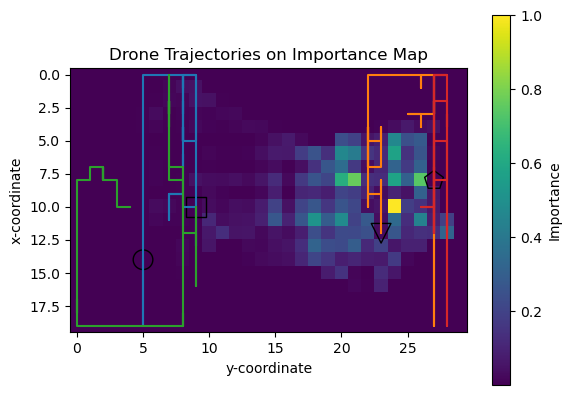

[1.766916307124582, -0.034166477620601876, 4.615455486294814, -1.8403000442082817]
Time | ep_step:  91 1
[1.940167189679798, 5.009717948734761, -4.152580976746975, -0.7944462988182865]
Time | ep_step:  92 2
[2.3263954522114965, 2.182025011087035, 3.406559069662297, 7.847715502420188]
Time | ep_step:  93 3
[2.7037853299305423, 2.3654346935620656, 4.853667863132026, -0.6115830591680282]
Time | ep_step:  94 4
[1.9598165452893601, 4.088522413894566, -4.469228884364302, 1.2560222617821721]
-----------
Episode:  19
Time | ep_step:  95 0
[3.0155732106298916, 4.151561971918937, 1.147800438192964, 3.8592705453512046]
Time | ep_step:  96 1
[3.1607291005929703, -3.964521710707161, -1.1882725022986986, 4.206676869111334]
Time | ep_step:  97 2
[3.394087399049445, 0.49166407025416076, 4.706289251391857, 4.25]
Time | ep_step:  98 3
[-3.4207724599096268, 1.9033706376299415, -4.428338175638488, 4.25]
Time | ep_step:  99 4
[3.4652498593260477, -0.43950099362060413, 4.303144731458153, -6.499999983589098e

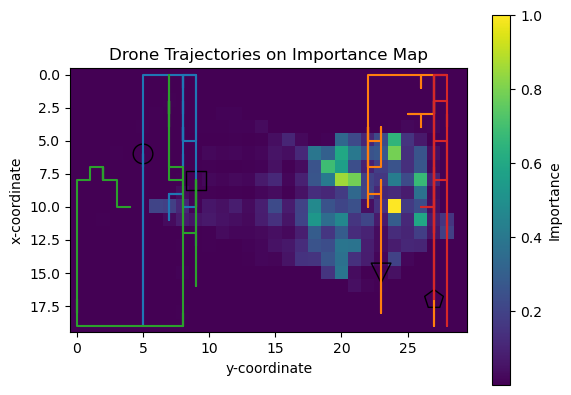

[-3.4846412896301935, 4.114361551331157, -4.193645413981779, 4.1249997500000015]
Time | ep_step:  101 1
[0.8184933741042094, 0.908116635009647, 4.082611117510835, -0.30000909999997727]
Time | ep_step:  102 2
[-0.7979484164639612, 4.533705286681653, -4.293341453668239, 0.4249999749999999]
Time | ep_step:  103 3
[4.398233774667396, 8.218757736682894, 3.966364301783268, 0.5000007349999986]
Time | ep_step:  104 4
[-4.4195699132301876, -0.5180320098996138, -3.517901598105782, 1.1875006249999975]
-----------
Episode:  21
Time | ep_step:  105 0
[1.332455937109296, -3.008281368017193, 3.367076779476877, 1.4575007149999986]
Time | ep_step:  106 1
[-1.3066333172598426, 5.439170401170852, -3.5934538289276974, 1.6403994635463492]
Time | ep_step:  107 2
[8.822186730090026, 4.4636672673747, 9.635763047954578, 4.634520248945149]
Time | ep_step:  108 3
[0.24385951381896925, 6.850445018112662, 2.7114091230563666, 3.62536565032772]
Time | ep_step:  109 4
[6.584748408753232, -2.0688449085196448, 4.409572

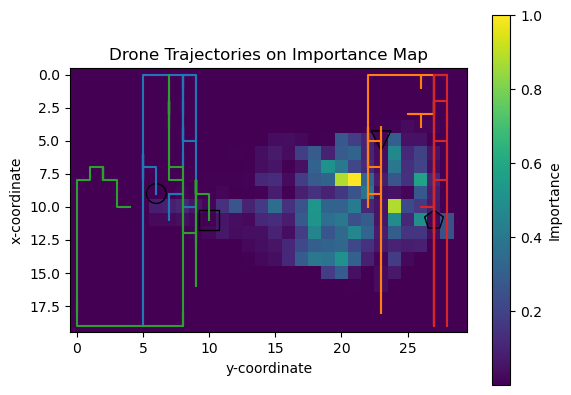

[4.416735918963141, 0.2756728907032391, 3.458892672019509, -3.61106596855699]
Time | ep_step:  111 1
[3.798745356408463, 4.135608205005903, 3.8953329519497832, 3.3846202134738093]
Time | ep_step:  112 2
[4.152995966368554, 4.2658912908074225, 4.238486276592159, 3.836705975168369]
Time | ep_step:  113 3
[4.303448567077229, 4.25, 4.346289253221915, 0.6981005508126981]
Time | ep_step:  114 4
[4.335572190825918, -0.7500099999999743, 4.853127636973811, 3.561367289502311]
-----------
Episode:  23
Time | ep_step:  115 0
[4.384595099990824, 0.8750008749999969, 4.709374988026182, 2.349015790662224]
Time | ep_step:  116 1
[4.315405800009177, -1.000002624999992, 4.25, 3.1679878368050494]
Time | ep_step:  117 2
[4.35000045, 4.687500874999998, -4.125009124999978, 4.385828057681852]
Time | ep_step:  118 3
[4.35000045, 5.125001749999996, 0.249999425000005, 4.217093206641522]
Time | ep_step:  119 4
[-0.18750862499997867, 5.062501874999995, 0.49999972500000334, 4.25]
-----------
Episode:  24
Time | ep_

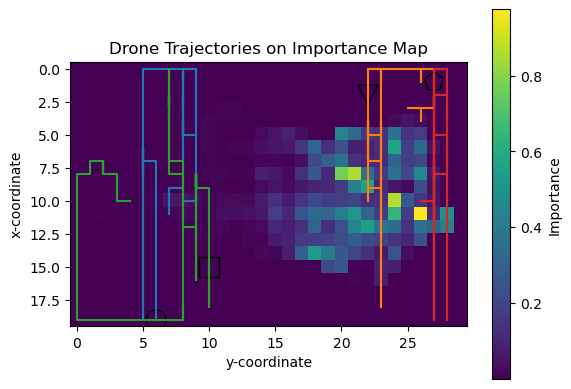

[0.3125000000000022, 4.3750005, 1.1875006499999998, -0.7500099999999743]
Time | ep_step:  121 1
[0.27499972499999925, 5.5597246433802585, 1.4787244125103016, 4.25]
Time | ep_step:  122 2
[0.9625006500000001, -5.434733268380238, 1.8995681500621946, 5.125001749999996]
Time | ep_step:  123 3
[1.1875006499999976, 5.211193209603328, -1.9654262122372224, 4.3750005]
Time | ep_step:  124 4
[1.4125006499999992, 6.497184578482117, 0.45132265239484987, 4.738157093015218]
-----------
Episode:  25
Time | ep_step:  125 0
[1.637500649999999, 9.630554165641607, 0.6320604972698771, 6.229712284216618]
Time | ep_step:  126 1
[7.650007299999978, -8.947564675543372, 3.6724999907278327e-07, 5.294921833013673]
Time | ep_step:  127 2
[1.9665003270151695, 7.683330327901902, 0.8862503149999965, 3.9003618977751597]
Time | ep_step:  128 3
[-1.964934182734937, 8.083716126903893, 1.7426266227499978, 8.368967635836391]
Time | ep_step:  129 4
[4.348425180719791, 7.955356116406619, 4.641256182499985, -2.07497838606383

In [6]:
# Set mode: random, greedy, lstm, nn
mode = 'gru'

pretrained_folder = r'\GRU_13_2_10000iter REAL.pth' # r'\GRU_128_3_10000iter.pth'

run(link, df_link, ['000'], id = 'pred_vdist', mode = mode, load = True, pretrained_folder=pretrained_folder)

In [7]:
list_of_perc_gru_2 = np.load(r'C:\Users\amelo\Documents\GitHub\Projet-CE-1\REAL DATA\Results\06_11_2025_23_46_46\list_of_perc_visited.npy')
list_reward_gru_2 = np.load(r'C:\Users\amelo\Documents\GitHub\Projet-CE-1\REAL DATA\Results\06_10_2025_19_04_47\list_of_reward_metric.npy')
list_patrol_gru_2 = np.load(r'C:\Users\amelo\Documents\GitHub\Projet-CE-1\REAL DATA\Results\06_10_2025_19_04_47\list_of_patrol_metric.npy')

# list_of_perc_gru_2 = np.load(r'D:\GitHub\Projet-CE-1\REAL DATA\Results\06_10_2025_19_04_47\list_of_perc_visited.npy')
# list_reward_gru_2 = np.load(r'D:\GitHub\Projet-CE-1\REAL DATA\Results\06_10_2025_19_04_47\list_of_reward_metric.npy')
# list_patrol_gru_2 = np.load(r'D:\GitHub\Projet-CE-1\REAL DATA\Results\06_10_2025_19_04_47\list_of_patrol_metric.npy')

In [8]:
list_of_perc_greedy = np.load(r'C:\Users\amelo\Documents\GitHub\Projet-CE-1\REAL DATA\Results\06_11_2025_15_02_02\list_of_perc_visited.npy')
list_reward_greedy = np.load(r'C:\Users\amelo\Documents\GitHub\Projet-CE-1\REAL DATA\Results\06_11_2025_15_02_02\list_of_reward_metric.npy')
list_patrol_greedy = np.load(r'C:\Users\amelo\Documents\GitHub\Projet-CE-1\REAL DATA\Results\06_11_2025_15_02_02\list_of_patrol_metric.npy')

# list_of_perc_greedy = np.load(r'D:\GitHub\Projet-CE-1\REAL DATA\Results\06_11_2025_15_02_02\list_of_perc_visited.npy')
# list_reward_greedy = np.load(r'D:\GitHub\Projet-CE-1\REAL DATA\Results\06_11_2025_15_02_02\list_of_reward_metric.npy')
# list_patrol_greedy = np.load(r'D:\GitHub\Projet-CE-1\REAL DATA\Results\06_11_2025_15_02_02\list_of_patrol_metric.npy')

In [9]:
list_of_perc_random = np.load(r'C:\Users\amelo\Documents\GitHub\Projet-CE-1\REAL DATA\Results\06_11_2025_15_06_10\list_of_perc_visited.npy')
list_reward_random = np.load(r'C:\Users\amelo\Documents\GitHub\Projet-CE-1\REAL DATA\Results\06_11_2025_15_06_10\list_of_reward_metric.npy')
list_patrol_random = np.load(r'C:\Users\amelo\Documents\GitHub\Projet-CE-1\REAL DATA\Results\06_11_2025_15_06_10\list_of_patrol_metric.npy')

# list_of_perc_random = np.load(r'D:\GitHub\Projet-CE-1\REAL DATA\Results\06_11_2025_15_06_10\list_of_perc_visited.npy')
# list_reward_random = np.load(r'D:\GitHub\Projet-CE-1\REAL DATA\Results\06_11_2025_15_06_10\list_of_reward_metric.npy')
# list_patrol_random = np.load(r'D:\GitHub\Projet-CE-1\REAL DATA\Results\06_11_2025_15_06_10\list_of_patrol_metric.npy')

In [10]:
def percentage_above(graphe1, graphe2):

    graphe1 = np.array(graphe1)
    graphe2 = np.array(graphe2)

    if len(graphe1) != len(graphe2):
        raise ValueError("Les deux graphes doivent avoir la même longueur.")

    nb_au_dessus = np.sum(graphe1 > graphe2)
    pourcentage = (nb_au_dessus / len(graphe1)) * 100

    print(f"GRU est au-dessus de LSTM dans {pourcentage:.2f}% des cas.")
    return pourcentage

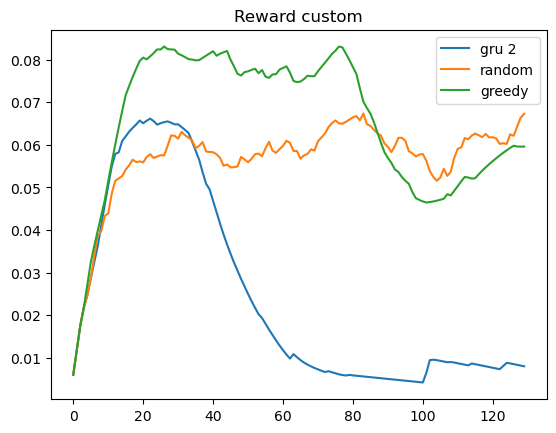

In [11]:
plt.plot(list_patrol_gru_2, label = 'gru 2')
plt.plot(list_patrol_random, label = 'random')
plt.plot(list_patrol_greedy, label = 'greedy')
plt.title('Reward custom')
plt.legend()

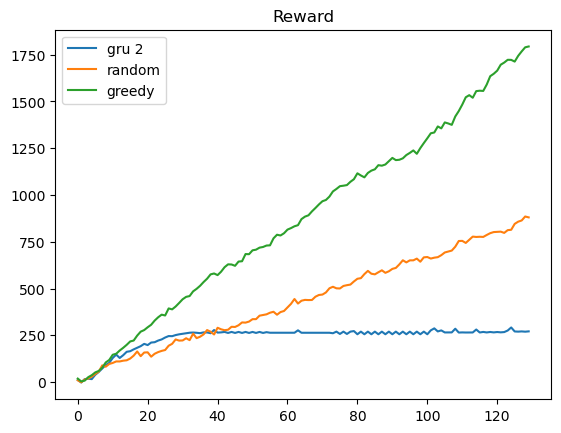

In [12]:
plt.plot(list_reward_gru_2, label = 'gru 2')
plt.plot(list_reward_random, label = 'random')
plt.plot(list_reward_greedy, label = 'greedy')
plt.title('Reward')
plt.legend()

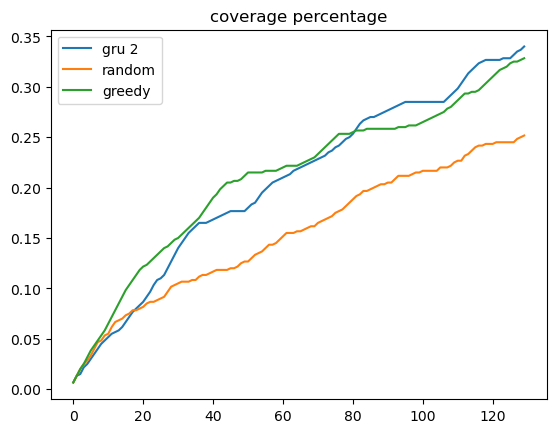

In [13]:
plt.plot(list_of_perc_gru_2, label = 'gru 2')
plt.plot(list_of_perc_random, label = 'random')
plt.plot(list_of_perc_greedy, label = 'greedy')
plt.title('coverage percentage')
plt.legend()